In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install timm tensorboard Pillow

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
from torchvision import transforms, datasets, models
from torchvision.datasets import OxfordIIITPet
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# 固定随机种子，保证每次跑的结果一样
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# 检测GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

使用设备: cuda


In [4]:
# 下载数据集（Kaggle网络OK，会自动下载）
full_dataset = OxfordIIITPet(root="./data", download=True, transform=None)

# 获取所有标签用于分层划分
labels = [full_dataset[i][1] for i in range(len(full_dataset))]

from collections import Counter
print(f"总样本数: {len(full_dataset)}")
print(f"类别数: {len(set(labels))}")

# 按 70:15:15 分层划分
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(sss.split(range(len(full_dataset)), labels))

temp_labels = [labels[i] for i in temp_idx]
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(sss2.split(range(len(temp_idx)), temp_labels))

# 映射回原始索引
val_idx = [temp_idx[i] for i in val_idx]
test_idx = [temp_idx[i] for i in test_idx]

print(f"训练集: {len(train_idx)}, 验证集: {len(val_idx)}, 测试集: {len(test_idx)}")

# 保存索引供后续使用
torch.save(train_idx, 'train_idx.pt')
torch.save(val_idx, 'val_idx.pt')
torch.save(test_idx, 'test_idx.pt')

100%|██████████| 792M/792M [00:19<00:00, 40.2MB/s] 
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.5MB/s]


总样本数: 3680
类别数: 37
训练集: 2576, 验证集: 552, 测试集: 552


In [5]:
# 训练集：增强 + 标准化
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 验证集/测试集：只做标准处理，不做随机增强
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 重新加载数据集，分别应用不同的transform
train_dataset = OxfordIIITPet(root="./data", download=False, transform=train_transform)
val_dataset = OxfordIIITPet(root="./data", download=False, transform=val_transform)
test_dataset = OxfordIIITPet(root="./data", download=False, transform=val_transform)

# 用之前保存的索引取子集
train_dataset = Subset(train_dataset, train_idx)
val_dataset = Subset(val_dataset, val_idx)
test_dataset = Subset(test_dataset, test_idx)

# 创建DataLoader
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# 检查一下数据形状
for images, labels in train_loader:
    print(f"输入Batch形状: {images.shape}")  # 应该是 [32, 3, 224, 224]
    break

输入Batch形状: torch.Size([32, 3, 224, 224])


In [18]:
def create_model(num_classes=37):
    # 加载预训练的ResNet18
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    # 替换最后一层全连接层，输出37类
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# 测试一下模型能否跑通
test_model = create_model()
test_input = torch.randn(1, 3, 224, 224)
test_output = test_model(test_input)
print(f"模型输出形状: {test_output.shape}")  # 应该是 [1, 37]

模型输出形状: torch.Size([1, 37])


In [17]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        # 重要：清零梯度（防止梯度累积）
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()  # 重要：切换到评估模式（关闭Dropout和BN的随机性）
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():  # 重要：不计算梯度，节省显存
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / total, correct / total, all_preds, all_labels

开始训练 Baseline...
Epoch 1/15 | Train Loss: 1.8845 | Train Acc: 0.5920 | Val Loss: 0.6992 | Val Acc: 0.8605
Epoch 2/15 | Train Loss: 0.5709 | Train Acc: 0.9154 | Val Loss: 0.4599 | Val Acc: 0.9040
Epoch 3/15 | Train Loss: 0.3071 | Train Acc: 0.9488 | Val Loss: 0.3778 | Val Acc: 0.9004
Epoch 4/15 | Train Loss: 0.1770 | Train Acc: 0.9767 | Val Loss: 0.3498 | Val Acc: 0.9149
Epoch 5/15 | Train Loss: 0.1171 | Train Acc: 0.9876 | Val Loss: 0.2924 | Val Acc: 0.9203
Epoch 6/15 | Train Loss: 0.0718 | Train Acc: 0.9957 | Val Loss: 0.3166 | Val Acc: 0.9203
Epoch 7/15 | Train Loss: 0.0493 | Train Acc: 0.9992 | Val Loss: 0.2797 | Val Acc: 0.9293
Epoch 8/15 | Train Loss: 0.0353 | Train Acc: 0.9981 | Val Loss: 0.2537 | Val Acc: 0.9330
Epoch 9/15 | Train Loss: 0.0274 | Train Acc: 0.9996 | Val Loss: 0.2969 | Val Acc: 0.9239
Epoch 10/15 | Train Loss: 0.0214 | Train Acc: 1.0000 | Val Loss: 0.2592 | Val Acc: 0.9293
Epoch 11/15 | Train Loss: 0.0169 | Train Acc: 1.0000 | Val Loss: 0.2614 | Val Acc: 0.9257
Ep

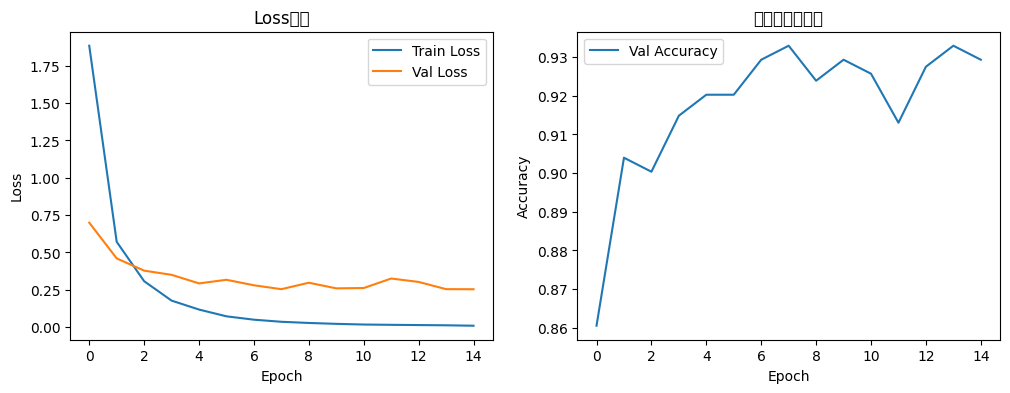

In [8]:
# 创建模型
model = create_model().to(device)

# 定义损失函数（CrossEntropyLoss自带Softmax，不需要额外加Softmax层！）
criterion = nn.CrossEntropyLoss()

# 优化器
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

# 训练参数
EPOCHS = 15
best_val_acc = 0

# 记录训练过程
train_losses = []
val_losses = []
val_accs = []

print("开始训练 Baseline...")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    # 保存最好的模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model_baseline.pth')
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"Baseline 最佳验证准确率: {best_val_acc:.4f}")

# 画训练曲线
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss曲线')

plt.subplot(1, 2, 2)
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('验证准确率曲线')
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [9]:
# 定义Label Smoothing损失函数
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing
    
    def forward(self, pred, target):
        n_classes = pred.size(-1)
        # 创建平滑标签
        smooth_target = torch.full_like(pred, self.smoothing / (n_classes - 1))
        smooth_target.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
        # 计算KL散度
        log_prob = nn.functional.log_softmax(pred, dim=-1)
        loss = -(smooth_target * log_prob).sum(dim=-1).mean()
        return loss

# 重新创建模型（从头训练）
model_ls = create_model().to(device)
criterion_ls = LabelSmoothingCrossEntropy(smoothing=0.1)
optimizer_ls = optim.AdamW(model_ls.parameters(), lr=1e-4)

best_val_acc_ls = 0
train_losses_ls = []
val_losses_ls = []
val_accs_ls = []

print("开始训练 Label Smoothing 消融实验...")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_ls, train_loader, optimizer_ls, criterion_ls, device)
    val_loss, val_acc, _, _ = evaluate(model_ls, val_loader, criterion_ls, device)
    
    train_losses_ls.append(train_loss)
    val_losses_ls.append(val_loss)
    val_accs_ls.append(val_acc)
    
    if val_acc > best_val_acc_ls:
        best_val_acc_ls = val_acc
        torch.save(model_ls.state_dict(), 'best_model_labelsmooth.pth')
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"Label Smoothing 最佳验证准确率: {best_val_acc_ls:.4f}")

# 对比结果表格
print("\n=== 实验结果对比 ===")
print(f"Baseline      | 最佳验证准确率: {best_val_acc:.4f}")
print(f"Label Smoothing | 最佳验证准确率: {best_val_acc_ls:.4f}")
print(f"提升: {(best_val_acc_ls - best_val_acc)*100:.2f}%")

开始训练 Label Smoothing 消融实验...
Epoch 1/15 | Train Loss: 2.1701 | Train Acc: 0.5846 | Val Loss: 1.2659 | Val Acc: 0.8732
Epoch 2/15 | Train Loss: 1.1198 | Train Acc: 0.9127 | Val Loss: 1.0844 | Val Acc: 0.8949
Epoch 3/15 | Train Loss: 0.9360 | Train Acc: 0.9542 | Val Loss: 1.0498 | Val Acc: 0.8841
Epoch 4/15 | Train Loss: 0.8496 | Train Acc: 0.9845 | Val Loss: 0.9902 | Val Acc: 0.9167
Epoch 5/15 | Train Loss: 0.7980 | Train Acc: 0.9938 | Val Loss: 1.0080 | Val Acc: 0.9130
Epoch 6/15 | Train Loss: 0.7768 | Train Acc: 0.9977 | Val Loss: 1.0073 | Val Acc: 0.9221
Epoch 7/15 | Train Loss: 0.7703 | Train Acc: 0.9969 | Val Loss: 1.0058 | Val Acc: 0.9112
Epoch 8/15 | Train Loss: 0.7535 | Train Acc: 1.0000 | Val Loss: 0.9905 | Val Acc: 0.9185
Epoch 9/15 | Train Loss: 0.7542 | Train Acc: 0.9996 | Val Loss: 0.9955 | Val Acc: 0.9203
Epoch 10/15 | Train Loss: 0.7429 | Train Acc: 0.9996 | Val Loss: 1.0095 | Val Acc: 0.9167
Epoch 11/15 | Train Loss: 0.7400 | Train Acc: 1.0000 | Val Loss: 0.9904 | Val Ac

测试集准确率: 0.9221


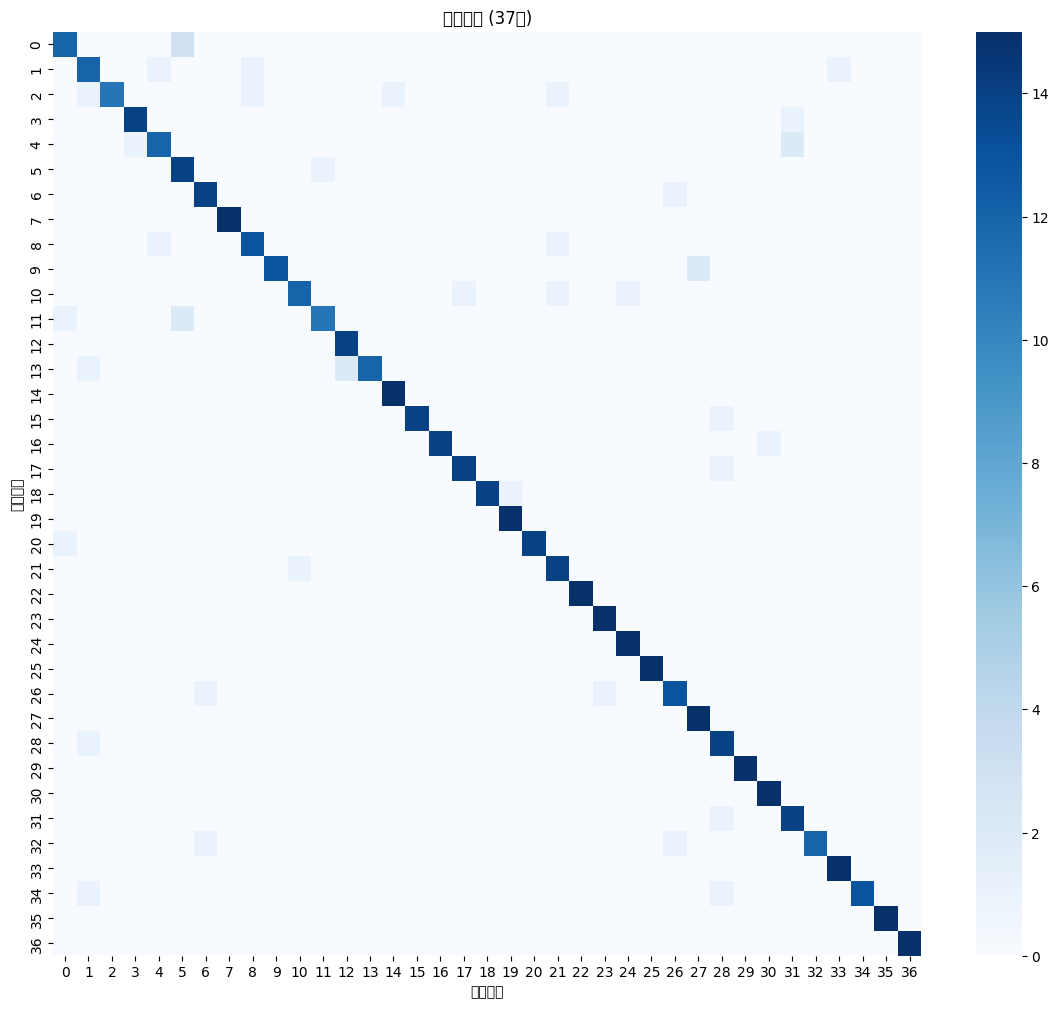

最容易被混淆的类别对: 0 <-> 5, 混淆次数: 3


In [10]:
# 加载最佳模型进行测试
model.load_state_dict(torch.load('best_model_baseline.pth'))
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)
print(f"测试集准确率: {test_acc:.4f}")

# 画混淆矩阵
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=range(37), yticklabels=range(37))
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.title('混淆矩阵 (37类)')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# 找出最容易被混淆的类别对
# 忽略对角线，找最大的非对角线值
np.fill_diagonal(cm, 0)
most_confused = np.unravel_index(np.argmax(cm), cm.shape)
print(f"最容易被混淆的类别对: {most_confused[0]} <-> {most_confused[1]}, 混淆次数: {cm[most_confused]}")

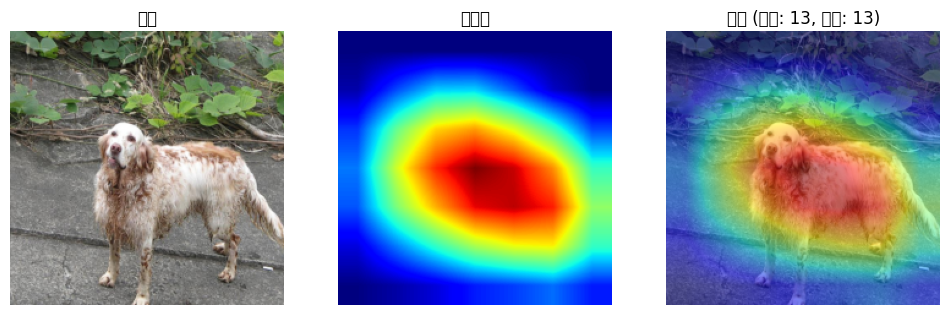

In [11]:
# 简化版Grad-CAM实现
from torch.nn import functional as F

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # 注册钩子
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    
    def generate(self, input_image, target_class):
        self.model.eval()
        # 前向传播
        output = self.model(input_image)
        self.model.zero_grad()
        # 目标类的梯度
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot)
        
        # 计算权重
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        # 加权激活
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().detach().numpy()
        # 归一化
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# 选择模型最后一层卷积层
target_layer = model.layer4[-1]
grad_cam = GradCAM(model, target_layer)

# 获取一张测试图片
test_iter = iter(test_loader)
images, labels = next(test_iter)
img = images[0:1].to(device)  # 取第一张
true_label = labels[0].item()

# 预测
with torch.no_grad():
    output = model(img)
    pred = torch.argmax(output, 1).item()

# 生成热力图
cam = grad_cam.generate(img, pred)

# 显示原图和热力图叠加
def show_cam_on_image(img_tensor, cam):
    # 反标准化
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.cpu() * std + mean
    img = img.numpy().transpose(1, 2, 0)
    img = np.clip(img, 0, 1)
    
    # 叠加热力图
    heatmap = plt.cm.jet(cam)[:, :, :3]
    overlay = 0.5 * img + 0.5 * heatmap
    overlay = np.clip(overlay, 0, 1)
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
    ax1.imshow(img)
    ax1.set_title('原图')
    ax1.axis('off')
    ax2.imshow(cam, cmap='jet')
    ax2.set_title('热力图')
    ax2.axis('off')
    ax3.imshow(overlay)
    ax3.set_title(f'叠加 (预测: {pred}, 真实: {true_label})')
    ax3.axis('off')
    plt.savefig('gradcam_example.png', dpi=150, bbox_inches='tight')
    plt.show()

show_cam_on_image(img[0], cam)

In [12]:
# 把所有结果打包下载
import zipfile

files_to_zip = [
    'best_model_baseline.pth',
    'best_model_labelsmooth.pth',
    'training_curves.png',
    'confusion_matrix.png',
    'gradcam_example.png'
]

with zipfile.ZipFile('results.zip', 'w') as zipf:
    for f in files_to_zip:
        if os.path.exists(f):
            zipf.write(f)

print("结果已打包为 results.zip")
print("点击右侧 'Output' 面板，下载 results.zip")

结果已打包为 results.zip
点击右侧 'Output' 面板，下载 results.zip
